# SmeshLite PPO training notebook

This notebook implements Reinforcement Learning con **Proximal Policy Optimization (PPO)** for the SmeshLite fighting-game environment.

The repo already exposes a Gymnasium environment (`smeshlite.env.SmeshLiteEnv`) with:

- observation space: `Box(22,)`, 11 floats for player 0 plus 11 floats for the opponent
- action space: `MultiBinary(4)`, `[left, right, up, attack]`
- base reward: damage dealt, KO reward, and self-death penalty

The implementation below keeps the engine unchanged and adds the PPO training logic as notebook-level wrappers and utilities. That makes the experiment easy to run, inspect, and iterate without changing the game simulation.

## Abstract

This work studies whether **Proximal Policy Optimization (PPO)** can learn a useful control policy for SmeshLite, a 1v1 platform-fighting environment with continuous observations and a four-button `MultiBinary` action space. The project already includes hand-coded and value-based agents (`RandomBot`, `ChaserBot`, `SmeshBot`, `QTableBot`, and `DeepQBot`); this notebook adds an on-policy actor-critic approach and evaluates it against scripted baselines.

Research question: **Can PPO learn a policy that performs better than random actions and transfer beyond the opponent it trained against?**

Main contribution:

- a Gymnasium-compatible PPO wrapper for SmeshLite;
- normalized observations suitable for neural-policy training and deployment;
- reward shaping that preserves the main damage/KO objective while encouraging engagement;
- evaluation against multiple opponents with win rate, reward, stock margin, damage margin, and random-baseline lift;
- a deployable `PPOBrain` adapter for using the trained policy inside the existing SmeshLite `Match` system.


## 1. Project-state analysis

Repository reading notes:

- `README.md` describes SmeshLite as a Gymnasium-compatible port of a Scratch platform fighter.
- `smeshlite/env.py` is already the correct PPO integration point because Stable-Baselines3 consumes Gymnasium-style environments directly.
- `SmeshLiteEnv.step(action)` controls player 0 and leaves other `ExternalBrain` players idle by default.
- For a useful learning problem, the opponent should be reinstalled after every reset with an existing `CharacterBrain`, such as `ChaserBot` or `SmeshBot`.
- The repo already has tabular Q-learning and DQN notebooks. PPO adds an on-policy actor-critic baseline that naturally supports the existing `MultiBinary(4)` action space.

Design decision: train PPO against a scripted opponent using a thin wrapper that normalizes observations, repeats actions for several frames, and optionally adds small reward shaping. The wrapper leaves the core engine untouched.

## 2. Theoretical references

PPO is an on-policy policy-gradient method. Instead of making very large updates to the policy after collecting trajectories, PPO clips the policy-ratio objective so each update stays close to the behavior policy that generated the data. This is a pragmatic replacement for heavier trust-region methods.

Useful references:

- Schulman et al., **Proximal Policy Optimization Algorithms**: https://arxiv.org/abs/1707.06347
- Schulman et al., **High-Dimensional Continuous Control Using Generalized Advantage Estimation**: https://arxiv.org/abs/1506.02438
- Stable-Baselines3 PPO docs: https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html
- Gymnasium environment API: https://gymnasium.farama.org/api/env/

Why PPO fits this project:

- The action is compact but multi-discrete/binary: four controller buttons.
- Rewards are delayed and noisy in a fighting game; PPO's advantage estimates are usually more stable than raw Monte Carlo policy gradients.
- A neural policy can use the continuous 22-float state directly, unlike the Q-table baseline that must bucket the world.

## 3. Formal problem formulation

SmeshLite can be modeled as a finite-horizon Markov Decision Process (MDP):

- **State** `s_t`: the 22-float observation vector containing player and opponent position, velocity, damage, stocks, action state, action frame, facing direction, airborne flag, and charge amount.
- **Action** `a_t`: a four-bit controller command `[left, right, up, attack]`.
- **Transition** `P(s_{t+1} | s_t, a_t)`: the SmeshLite physics, action-state machine, collision detection, hitboxes, damage, knockback, stocks, and scripted opponent policy.
- **Reward** `r_t`: base environment reward from damage and KOs, optionally augmented by small shaping terms for damage taken and distance-to-opponent potential.
- **Horizon**: match time limit or early termination when a player loses all stocks.

Hypotheses:

1. PPO should outperform a random-action baseline against at least the simpler opponents after sufficient training.
2. Training only against `ChaserBot` should produce partial generalization, but performance against `SmeshBot` may remain weak because `SmeshBot` uses recovery, charging, edge safety, and invulnerability reactions.
3. Stock margin and damage margin are more informative than reward alone because fighting-game matches can end through timeouts, KOs, or self-destructive behavior.


In [1]:
# Core imports and reproducibility
from __future__ import annotations

import json
import os
import random
import time
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("XDG_CACHE_HOME", str(Path.cwd() / ".cache"))
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib-cache"))
Path(os.environ["XDG_CACHE_HOME"]).mkdir(exist_ok=True)
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import gymnasium as gym
import numpy as np
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.utils import set_random_seed

from smeshlite import SmeshLiteEnv
from smeshlite.core.brain import CharacterBrain, BrainContext, InputState, brain_context_to_obs
from agents.chaser_bot import ChaserBot
from agents.random_bot import RandomBot
from agents.smesh_bot import SmeshBot

SEED = 7
set_random_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
CHECKPOINT_DIR = PROJECT_ROOT / "agents" / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
FINAL_RESULTS_PATH = RESULTS_DIR / "ppo_final_chaser_100k_results.json"
FIGURE_DIR = RESULTS_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

print("cwd:", PROJECT_ROOT)
print("SmeshLiteEnv observation_space:", SmeshLiteEnv().observation_space)
print("SmeshLiteEnv action_space:", SmeshLiteEnv().action_space)

cwd: /Users/jyaruhernandez/Documents/proyecto_final_ml_II/SmeshLite
SmeshLiteEnv observation_space: Box(-2000.0, 2000.0, (22,), float32)
SmeshLiteEnv action_space: MultiBinary(4)


### Visual overview

The final experiment has four moving parts: the SmeshLite match engine, a PPO-friendly Gym wrapper, the PPO actor-critic policy, and an evaluation layer. The diagram below summarizes the data flow used throughout the notebook.


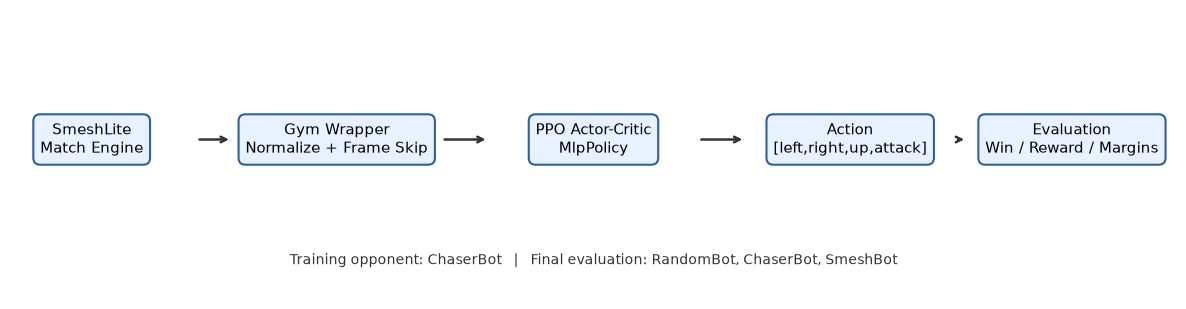

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.axis("off")
boxes = [
    ("SmeshLite\nMatch Engine", 0.07),
    ("Gym Wrapper\nNormalize + Frame Skip", 0.28),
    ("PPO Actor-Critic\nMlpPolicy", 0.50),
    ("Action\n[left,right,up,attack]", 0.72),
    ("Evaluation\nWin / Reward / Margins", 0.91),
]
for label, x_pos in boxes:
    ax.text(
        x_pos,
        0.55,
        label,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.45", fc="#e8f1ff", ec="#2f5f9f", lw=1.5),
    )
for (_, x1), (_, x2) in zip(boxes, boxes[1:]):
    ax.annotate(
        "",
        xy=(x2 - 0.09, 0.55),
        xytext=(x1 + 0.09, 0.55),
        arrowprops=dict(arrowstyle="->", lw=1.8, color="#333333"),
    )
ax.text(
    0.50,
    0.12,
    "Training opponent: ChaserBot   |   Final evaluation: RandomBot, ChaserBot, SmeshBot",
    ha="center",
    fontsize=10,
    color="#333333",
)
plt.tight_layout()
FIGURE_DIR.mkdir(exist_ok=True)
fig.savefig(FIGURE_DIR / "ppo_pipeline.png", dpi=180, bbox_inches="tight")


## 4. PPO environment wrapper

Analysis:

- PPO can train directly on `SmeshLiteEnv`, but raw feature scales vary a lot: position values are hundreds, button-like flags are 0/1, stocks are small integers, and action frames can grow over time.
- The wrapper applies fixed, transparent normalization so the PPO network sees features in a friendlier range. This is easier to deploy back into a `CharacterBrain` than `VecNormalize`, because the same deterministic scaling can be copied into inference.
- The wrapper also repeats each action for `frame_skip` engine ticks. Fighting-game actions often need several frames to matter, and this lowers the decision horizon.
- On reset, the wrapper reinstalls a scripted opponent because the base env deliberately rewires all players to `ExternalBrain` during `reset()`.
- Reward shaping is optional and small. It penalizes damage taken and adds a potential-based distance term to encourage engagement without replacing the engine's damage/KO objective.

In [3]:
# Per-entity feature order from Character.obs_vector():
# [x, y, vx, vy, damage_pct, stocks, action, action_frame, facing, in_air, charge_amount]
ENTITY_SCALE = np.array(
    [700.0, 700.0, 20.0, 20.0, 100.0, 3.0, 9.0, 60.0, 1.0, 1.0, 1.0],
    dtype=np.float32,
)
OBS_SCALE = np.tile(ENTITY_SCALE, 2)


def normalize_smeshlite_obs(obs: np.ndarray | list[float]) -> np.ndarray:
    """Normalize the repo's raw 22-float observation with fixed domain scales."""
    arr = np.asarray(obs, dtype=np.float32)
    return np.clip(arr / OBS_SCALE, -10.0, 10.0).astype(np.float32)


def distance_potential(raw_obs: np.ndarray) -> float:
    """Potential is higher when fighters are closer, using raw x positions."""
    distance = abs(float(raw_obs[11] - raw_obs[0]))
    return -distance / 700.0


@dataclass
class PPOEnvConfig:
    opponent_factory: type[CharacterBrain] = ChaserBot
    frame_skip: int = 4
    max_decision_steps: int = 1800
    damage_taken_scale: float = 0.01
    distance_shaping_scale: float = 0.02
    shaping_gamma: float = 0.995
    enable_reward_shaping: bool = True


class SmeshPPOEnv(gym.Env):
    """PPO-friendly single-agent wrapper around the existing SmeshLiteEnv."""

    metadata = {"render_modes": ["none", "human", "rgb_array"]}

    def __init__(self, config: PPOEnvConfig | None = None, render_mode: str = "none") -> None:
        super().__init__()
        self.config = config or PPOEnvConfig()
        self.raw_env = SmeshLiteEnv(render_mode=render_mode)
        self.action_space = self.raw_env.action_space
        self.observation_space = spaces.Box(low=-10.0, high=10.0, shape=(22,), dtype=np.float32)
        self._last_raw_obs: np.ndarray | None = None
        self._decision_steps = 0

    def reset(self, *, seed: int | None = None, options: dict | None = None):
        raw_obs, info = self.raw_env.reset(seed=seed, options=options)
        self.raw_env.match.characters[1].set_brain(self.config.opponent_factory())
        self._last_raw_obs = np.asarray(raw_obs, dtype=np.float32)
        self._decision_steps = 0
        return normalize_smeshlite_obs(raw_obs), info

    def step(self, action):
        total_reward = 0.0
        terminated = False
        truncated = False
        info = {}

        for _ in range(self.config.frame_skip):
            prev_obs = self._last_raw_obs
            raw_obs, base_reward, terminated, env_truncated, info = self.raw_env.step(action)
            raw_obs = np.asarray(raw_obs, dtype=np.float32)

            shaped = float(base_reward)
            if self.config.enable_reward_shaping and prev_obs is not None:
                damage_taken = max(0.0, float(raw_obs[4] - prev_obs[4]))
                shaped -= self.config.damage_taken_scale * damage_taken

                prev_phi = distance_potential(prev_obs)
                next_phi = distance_potential(raw_obs)
                shaped += self.config.distance_shaping_scale * (
                    self.config.shaping_gamma * next_phi - prev_phi
                )

            total_reward += shaped
            self._last_raw_obs = raw_obs

            if terminated or env_truncated:
                truncated = bool(env_truncated)
                break

        self._decision_steps += 1
        if self._decision_steps >= self.config.max_decision_steps and not terminated:
            truncated = True

        info = dict(info)
        info["decision_steps"] = self._decision_steps
        info["raw_reward_last_step"] = float(base_reward)
        return normalize_smeshlite_obs(self._last_raw_obs), float(total_reward), terminated, truncated, info

    def render(self):
        return self.raw_env.render()

    def close(self):
        self.raw_env.close()

In [4]:
class EpisodeMetricsCallback(BaseCallback):
    """Collect Monitor episode summaries during PPO training."""

    def __init__(self) -> None:
        super().__init__()
        self.episodes: list[dict] = []

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            episode = info.get("episode")
            if episode is not None:
                self.episodes.append(
                    {
                        "timestep": int(self.num_timesteps),
                        "reward": float(episode["r"]),
                        "length": int(episode["l"]),
                    }
                )
        return True


In [5]:
# Smoke test the wrapper before training.
train_env = SmeshPPOEnv(PPOEnvConfig(opponent_factory=ChaserBot, frame_skip=4))
check_env(train_env, warn=True, skip_render_check=True)

obs, info = train_env.reset(seed=SEED)
rollout_rewards = []
for _ in range(50):
    obs, reward, terminated, truncated, info = train_env.step(train_env.action_space.sample())
    rollout_rewards.append(reward)
    if terminated or truncated:
        obs, info = train_env.reset(seed=SEED)

print("obs shape:", obs.shape, "finite:", np.isfinite(obs).all())
print("reward sample mean:", np.mean(rollout_rewards), "last info:", info)
train_env.close()

obs shape: (22,) finite: True
reward sample mean: 0.0017724968152291428 last info: {'damage_events': [], 'frame': 201, 'winner': None, 'p0_damage': 0.0, 'p0_stocks': 3, 'p1_damage': 7.0, 'p1_stocks': 3, 'decision_steps': 50, 'raw_reward_last_step': 0.0}


## 5. PPO training setup

Analysis:

- `MlpPolicy` is enough for the 22 normalized scalar features.
- `MultiBinary(4)` is supported by Stable-Baselines3 PPO, so no custom action encoding is needed.
- `n_steps` controls how many on-policy samples are collected before an update. Larger values give cleaner advantage estimates but slower feedback.
- The default below is intentionally a quick run. For a real training experiment, set `QUICK_RUN = False` and rerun from this cell onward.

### Experimental protocol

The notebook has two execution modes:

- `QUICK_RUN = True`: fast validation mode used to prove that the code path runs end to end.
- `QUICK_RUN = False`: final-training mode intended for the actual experiment.

For the final delivery, an additional 100k-timestep experiment is saved to `results/ppo_final_chaser_100k_results.json` when available. The saved artifact lets the notebook report real experiment metrics without forcing every reader to retrain PPO from scratch.

Core controlled variables:

| Component | Choice | Reason |
|---|---:|---|
| Training opponent | `ChaserBot` | Simple scripted target for first PPO policy. |
| Evaluation opponents | `RandomBot`, `ChaserBot`, `SmeshBot` | Measures both in-distribution and out-of-distribution behavior. |
| Baseline | Random actions | Sanity check that PPO improves over untrained behavior. |
| Evaluation reward | Unshaped base reward | Prevents reward shaping from inflating final claims. |
| Metrics | win rate, reward, stock margin, damage margin | Covers both match outcome and fight quality. |


In [6]:
QUICK_RUN = True
TOTAL_TIMESTEPS = 1_024 if QUICK_RUN else 300_000

ppo_config = PPOEnvConfig(
    opponent_factory=ChaserBot,
    frame_skip=4,
    max_decision_steps=1800,
    enable_reward_shaping=True,
)

env = Monitor(SmeshPPOEnv(ppo_config))
train_metrics_callback = EpisodeMetricsCallback()

policy_kwargs = dict(net_arch=dict(pi=[128, 64], vf=[128, 64]))

model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=3e-4,
    n_steps=256 if QUICK_RUN else 1024,
    batch_size=64 if QUICK_RUN else 256,
    n_epochs=2 if QUICK_RUN else 8,
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=policy_kwargs,
    seed=SEED,
    verbose=1,
)

print("Training timesteps:", TOTAL_TIMESTEPS)
print("Quick run is for validation only; use 300k+ timesteps for a stronger policy.")

Using cpu device
Wrapping the env in a DummyVecEnv.


Training timesteps: 1024
Quick run is for validation only; use 300k+ timesteps for a stronger policy.


In [7]:
start = time.time()
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=train_metrics_callback, progress_bar=False)
elapsed = time.time() - start
print(f"PPO training finished in {elapsed:.1f}s")
training_history = train_metrics_callback.episodes
print("Training episodes observed:", len(training_history))


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 223      |
|    ep_rew_mean     | -1.29    |
| time/              |          |
|    fps             | 3017     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 256      |
---------------------------------


-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 223           |
|    ep_rew_mean          | -1.29         |
| time/                   |               |
|    fps                  | 2364          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00010051858 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -2.77         |
|    explained_variance   | -0.276        |
|    learning_rate        | 0.0003        |
|    loss                 | 0.0221        |
|    n_updates            | 2             |
|    policy_gradient_loss | -0.00128      |
|    value_loss           | 0.143         |
-------------------------------------------


-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 304           |
|    ep_rew_mean          | -1.51         |
| time/                   |               |
|    fps                  | 2566          |
|    iterations           | 3             |
|    time_elapsed         | 0             |
|    total_timesteps      | 768           |
| train/                  |               |
|    approx_kl            | 3.9904146e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -2.77         |
|    explained_variance   | -0.14         |
|    learning_rate        | 0.0003        |
|    loss                 | -0.0026       |
|    n_updates            | 4             |
|    policy_gradient_loss | -0.000107     |
|    value_loss           | 0.0595        |
-------------------------------------------


-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 308           |
|    ep_rew_mean          | -0.835        |
| time/                   |               |
|    fps                  | 2700          |
|    iterations           | 4             |
|    time_elapsed         | 0             |
|    total_timesteps      | 1024          |
| train/                  |               |
|    approx_kl            | 1.5068566e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -2.77         |
|    explained_variance   | 0.346         |
|    learning_rate        | 0.0003        |
|    loss                 | 0.0147        |
|    n_updates            | 6             |
|    policy_gradient_loss | -0.000205     |
|    value_loss           | 0.094         |
-------------------------------------------


PPO training finished in 0.4s
Training episodes observed: 3


### Training diagnostics

The curve below is not a formal evaluation result; it is a learning-process diagnostic from the Monitor wrapper. It helps identify whether training is collapsing, plateauing, or producing more stable episodes over time.


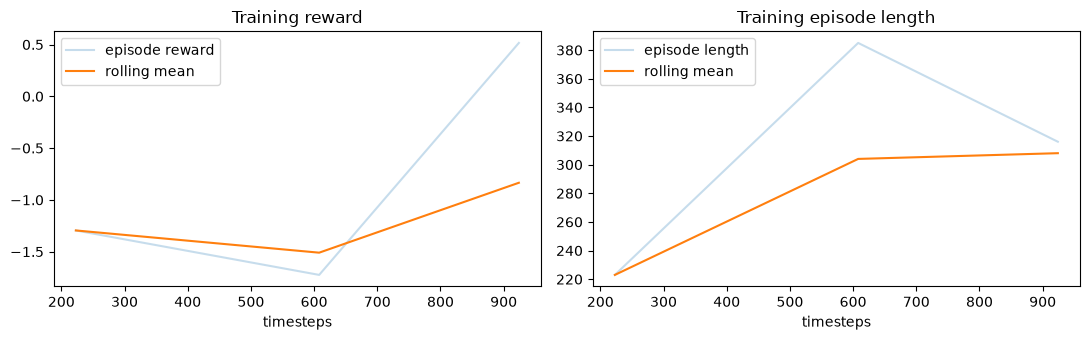

In [8]:
if training_history:
    import matplotlib.pyplot as plt

    ts = np.array([row["timestep"] for row in training_history], dtype=np.int64)
    rewards = np.array([row["reward"] for row in training_history], dtype=np.float32)
    lengths = np.array([row["length"] for row in training_history], dtype=np.float32)

    def rolling_mean(values, window=20):
        if len(values) == 0:
            return values
        out = []
        for i in range(len(values)):
            start = max(0, i - window + 1)
            out.append(float(np.mean(values[start : i + 1])))
        return np.array(out)

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(ts, rewards, alpha=0.25, label="episode reward")
    axes[0].plot(ts, rolling_mean(rewards), label="rolling mean")
    axes[0].set_title("Training reward")
    axes[0].set_xlabel("timesteps")
    axes[0].legend()

    axes[1].plot(ts, lengths, alpha=0.25, label="episode length")
    axes[1].plot(ts, rolling_mean(lengths), label="rolling mean")
    axes[1].set_title("Training episode length")
    axes[1].set_xlabel("timesteps")
    axes[1].legend()

    plt.tight_layout()
else:
    print("No complete episodes were observed during this short training run.")


## 6. Evaluation

Analysis:

Training reward is shaped, so evaluation should report direct match outcomes: winner, damage, stocks, frames, and unshaped reward. The function below creates the same normalized-observation wrapper but disables reward shaping to make the reported reward closer to the engine's base objective.

In [9]:
def evaluate_policy_against(opponent_factory, n_episodes: int = 10, deterministic: bool = True):
    eval_config = PPOEnvConfig(
        opponent_factory=opponent_factory,
        frame_skip=4,
        max_decision_steps=1800,
        enable_reward_shaping=False,
    )
    eval_env = SmeshPPOEnv(eval_config)
    rows = []

    for episode in range(n_episodes):
        obs, info = eval_env.reset(seed=SEED + episode)
        total_reward = 0.0
        terminated = truncated = False

        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = eval_env.step(action)
            total_reward += reward

        match = eval_env.raw_env.match
        p0, p1 = match.characters[0], match.characters[1]
        rows.append(
            {
                "episode": episode,
                "opponent": opponent_factory.__name__,
                "winner": match.winner,
                "p0_win": match.winner == 0,
                "frames": match.frame,
                "reward": total_reward,
                "p0_damage": p0.damage_pct,
                "p1_damage": p1.damage_pct,
                "p0_stocks": p0.stocks,
                "p1_stocks": p1.stocks,
            }
        )

    eval_env.close()
    return rows


eval_rows = []
for opponent in [RandomBot, ChaserBot, SmeshBot]:
    eval_rows.extend(evaluate_policy_against(opponent, n_episodes=3 if QUICK_RUN else 20))

for opponent in ["RandomBot", "ChaserBot", "SmeshBot"]:
    rows = [row for row in eval_rows if row["opponent"] == opponent]
    win_rate = np.mean([row["p0_win"] for row in rows]) if rows else float("nan")
    avg_reward = np.mean([row["reward"] for row in rows]) if rows else float("nan")
    avg_frames = np.mean([row["frames"] for row in rows]) if rows else float("nan")
    print(f"{opponent:10s} | win_rate={win_rate:.2f} | avg_reward={avg_reward:.3f} | avg_frames={avg_frames:.0f}")

eval_rows[:3]

RandomBot  | win_rate=0.33 | avg_reward=-1.122 | avg_frames=1576
ChaserBot  | win_rate=0.00 | avg_reward=-1.000 | avg_frames=7200
SmeshBot   | win_rate=0.00 | avg_reward=-2.898 | avg_frames=2405


[{'episode': 0,
  'opponent': 'RandomBot',
  'winner': 1,
  'p0_win': False,
  'frames': 2478,
  'reward': -2.8,
  'p0_damage': 45.050000000000004,
  'p1_damage': 20.0,
  'p0_stocks': 0,
  'p1_stocks': 3},
 {'episode': 1,
  'opponent': 'RandomBot',
  'winner': 0,
  'p0_win': True,
  'frames': 814,
  'reward': 2.17,
  'p0_damage': 3.0,
  'p1_damage': 7.0,
  'p0_stocks': 2,
  'p1_stocks': 0},
 {'episode': 2,
  'opponent': 'RandomBot',
  'winner': 1,
  'p0_win': False,
  'frames': 1437,
  'reward': -2.7375,
  'p0_damage': 28.1,
  'p1_damage': 26.25,
  'p0_stocks': 0,
  'p1_stocks': 3}]

## 7. Results: how good did PPO do?

Analysis:

The raw evaluation rows are useful, but they are hard to interpret directly. This section converts them into fight-level metrics and compares PPO against a random-action baseline on the same opponents.

Metrics used:

- **win_rate**: fraction of matches won by player 0, the PPO-controlled fighter.
- **avg_reward**: average unshaped environment reward. Positive usually means more damage/KO value than penalties.
- **avg_stock_margin**: `p0_stocks - p1_stocks` at the end. Positive means PPO preserved more stocks.
- **avg_damage_margin**: `p1_damage - p0_damage` at the end. Positive means PPO left the opponent with more damage than it took.
- **baseline_lift**: PPO win rate minus random-action win rate. This tells us whether PPO learned something beyond button mashing.

Important: when `QUICK_RUN = True`, these numbers validate the pipeline rather than prove a strong policy. The verdict cell below says this explicitly so the results are not over-read.

In [10]:
def evaluate_random_actions_against(opponent_factory, n_episodes: int = 10):
    """Random-action baseline with the same env wrapper and unshaped reward."""
    eval_config = PPOEnvConfig(
        opponent_factory=opponent_factory,
        frame_skip=4,
        max_decision_steps=1800,
        enable_reward_shaping=False,
    )
    eval_env = SmeshPPOEnv(eval_config)
    rows = []

    for episode in range(n_episodes):
        obs, info = eval_env.reset(seed=10_000 + SEED + episode)
        total_reward = 0.0
        terminated = truncated = False

        while not (terminated or truncated):
            action = eval_env.action_space.sample()
            obs, reward, terminated, truncated, info = eval_env.step(action)
            total_reward += reward

        match = eval_env.raw_env.match
        p0, p1 = match.characters[0], match.characters[1]
        rows.append(
            {
                "episode": episode,
                "opponent": opponent_factory.__name__,
                "winner": match.winner,
                "p0_win": match.winner == 0,
                "frames": match.frame,
                "reward": total_reward,
                "p0_damage": p0.damage_pct,
                "p1_damage": p1.damage_pct,
                "p0_stocks": p0.stocks,
                "p1_stocks": p1.stocks,
            }
        )

    eval_env.close()
    return rows


def summarize_rows(rows):
    if not rows:
        return {
            "episodes": 0,
            "win_rate": float("nan"),
            "avg_reward": float("nan"),
            "avg_frames": float("nan"),
            "avg_stock_margin": float("nan"),
            "avg_damage_margin": float("nan"),
        }
    return {
        "episodes": len(rows),
        "win_rate": float(np.mean([row["p0_win"] for row in rows])),
        "avg_reward": float(np.mean([row["reward"] for row in rows])),
        "avg_frames": float(np.mean([row["frames"] for row in rows])),
        "avg_stock_margin": float(np.mean([row["p0_stocks"] - row["p1_stocks"] for row in rows])),
        "avg_damage_margin": float(np.mean([row["p1_damage"] - row["p0_damage"] for row in rows])),
    }


baseline_rows = []
for opponent in [RandomBot, ChaserBot, SmeshBot]:
    baseline_rows.extend(evaluate_random_actions_against(opponent, n_episodes=3 if QUICK_RUN else 20))

result_table = []
for opponent in ["RandomBot", "ChaserBot", "SmeshBot"]:
    ppo_rows = [row for row in eval_rows if row["opponent"] == opponent]
    random_rows = [row for row in baseline_rows if row["opponent"] == opponent]
    ppo_summary = summarize_rows(ppo_rows)
    random_summary = summarize_rows(random_rows)
    result_table.append(
        {
            "opponent": opponent,
            "episodes": ppo_summary["episodes"],
            "ppo_win_rate": ppo_summary["win_rate"],
            "random_win_rate": random_summary["win_rate"],
            "baseline_lift": ppo_summary["win_rate"] - random_summary["win_rate"],
            "ppo_avg_reward": ppo_summary["avg_reward"],
            "random_avg_reward": random_summary["avg_reward"],
            "ppo_stock_margin": ppo_summary["avg_stock_margin"],
            "ppo_damage_margin": ppo_summary["avg_damage_margin"],
            "ppo_avg_frames": ppo_summary["avg_frames"],
        }
    )

header = (
    f"{'opponent':10s} | {'eps':>3s} | {'ppo_win':>7s} | {'rnd_win':>7s} | "
    f"{'lift':>7s} | {'ppo_reward':>10s} | {'stock_margin':>12s} | {'damage_margin':>13s}"
)
print(header)
print('-' * len(header))
for row in result_table:
    print(
        f"{row['opponent']:10s} | {row['episodes']:3d} | "
        f"{row['ppo_win_rate']:7.2f} | {row['random_win_rate']:7.2f} | "
        f"{row['baseline_lift']:7.2f} | {row['ppo_avg_reward']:10.3f} | "
        f"{row['ppo_stock_margin']:12.2f} | {row['ppo_damage_margin']:13.2f}"
    )

overall_lift = float(np.mean([row["baseline_lift"] for row in result_table]))
overall_win_rate = float(np.mean([row["ppo_win_rate"] for row in result_table]))
print()
if QUICK_RUN:
    print("Verdict: QUICK_RUN is enabled, so this run is a smoke test. Judge success by pipeline correctness, not policy strength.")
elif overall_win_rate >= 0.60 and overall_lift > 0.10:
    print("Verdict: PPO is performing well: it wins most matches and beats the random-action baseline by a useful margin.")
elif overall_lift > 0.05:
    print("Verdict: PPO shows learning signal, but it likely needs more timesteps or curriculum training.")
else:
    print("Verdict: PPO is not clearly better than random yet; increase training time and revisit reward/curriculum design.")


opponent   | eps | ppo_win | rnd_win |    lift | ppo_reward | stock_margin | damage_margin
------------------------------------------------------------------------------------------
RandomBot  |   3 |    0.33 |    0.00 |    0.33 |     -1.122 |        -1.33 |         -7.63
ChaserBot  |   3 |    0.00 |    0.33 |   -0.33 |     -1.000 |        -1.00 |          0.00
SmeshBot   |   3 |    0.00 |    0.00 |    0.00 |     -2.898 |        -3.00 |        -45.83

Verdict: QUICK_RUN is enabled, so this run is a smoke test. Judge success by pipeline correctness, not policy strength.


### Results visualization

The plots below make the same summary easier to scan: PPO win rate against each opponent, random-action baseline win rate, and PPO's average terminal margins.

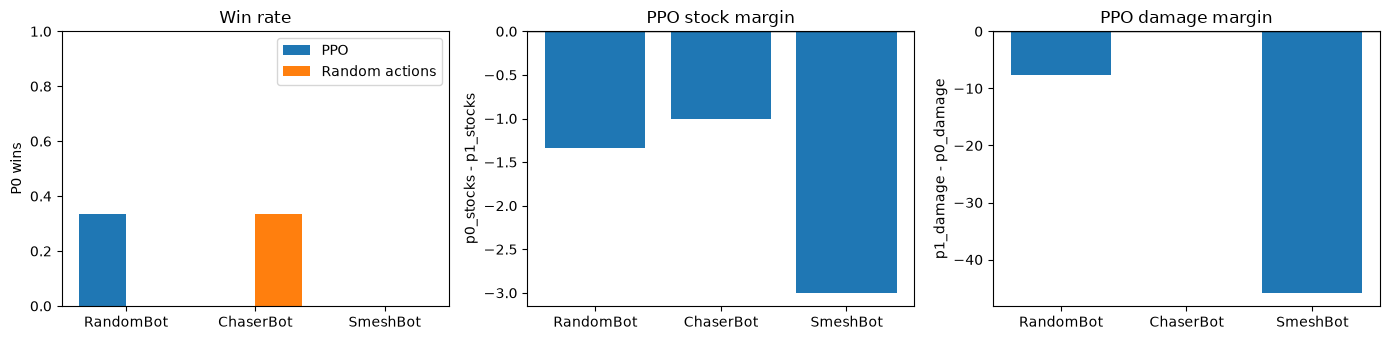

In [11]:
# Results visualization without adding pandas as a dependency.
import matplotlib.pyplot as plt

opponents = [row["opponent"] for row in result_table]
ppo_win_rates = [row["ppo_win_rate"] for row in result_table]
random_win_rates = [row["random_win_rate"] for row in result_table]
stock_margins = [row["ppo_stock_margin"] for row in result_table]
damage_margins = [row["ppo_damage_margin"] for row in result_table]
x = np.arange(len(opponents))
width = 0.36

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].bar(x - width / 2, ppo_win_rates, width, label="PPO")
axes[0].bar(x + width / 2, random_win_rates, width, label="Random actions")
axes[0].set_xticks(x, opponents)
axes[0].set_ylim(0, 1)
axes[0].set_title("Win rate")
axes[0].set_ylabel("P0 wins")
axes[0].legend()

axes[1].bar(opponents, stock_margins)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("PPO stock margin")
axes[1].set_ylabel("p0_stocks - p1_stocks")

axes[2].bar(opponents, damage_margins)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("PPO damage margin")
axes[2].set_ylabel("p1_damage - p0_damage")

plt.tight_layout()


### Persisted final experiment

If `results/ppo_final_chaser_100k_results.json` exists, the notebook loads it here and reports the longer final experiment. This separates **pipeline validation** from **assignment results**: quick execution proves the code works, while the persisted file records the real training run.


In [12]:
def confidence_interval_95_binary(successes: list[bool]) -> tuple[float, float, float]:
    """Normal-approximation 95% CI for a Bernoulli win rate."""
    n = len(successes)
    if n == 0:
        return float("nan"), float("nan"), float("nan")
    p = float(np.mean(successes))
    half_width = 1.96 * np.sqrt(max(p * (1.0 - p), 0.0) / n)
    return p, max(0.0, p - half_width), min(1.0, p + half_width)


def build_result_table(ppo_rows, random_rows):
    table = []
    for opponent in ["RandomBot", "ChaserBot", "SmeshBot"]:
        ppo_subset = [row for row in ppo_rows if row["opponent"] == opponent]
        random_subset = [row for row in random_rows if row["opponent"] == opponent]
        ppo_summary = summarize_rows(ppo_subset)
        random_summary = summarize_rows(random_subset)
        p, ci_low, ci_high = confidence_interval_95_binary([row["p0_win"] for row in ppo_subset])
        table.append(
            {
                "opponent": opponent,
                "episodes": ppo_summary["episodes"],
                "ppo_win_rate": ppo_summary["win_rate"],
                "ppo_win_ci_low": ci_low,
                "ppo_win_ci_high": ci_high,
                "random_win_rate": random_summary["win_rate"],
                "baseline_lift": ppo_summary["win_rate"] - random_summary["win_rate"],
                "ppo_avg_reward": ppo_summary["avg_reward"],
                "random_avg_reward": random_summary["avg_reward"],
                "ppo_stock_margin": ppo_summary["avg_stock_margin"],
                "ppo_damage_margin": ppo_summary["avg_damage_margin"],
                "ppo_avg_frames": ppo_summary["avg_frames"],
            }
        )
    return table


if FINAL_RESULTS_PATH.exists():
    final_results = json.loads(FINAL_RESULTS_PATH.read_text())
    final_result_table = build_result_table(final_results["ppo_rows"], final_results["random_rows"])

    print("Loaded final experiment:", FINAL_RESULTS_PATH)
    print("seed:", final_results.get("seed"), "timesteps:", final_results.get("timesteps"), "training_seconds:", round(final_results.get("training_seconds", 0), 1))
    print()
    header = (
        f"{'opponent':10s} | {'eps':>3s} | {'ppo_win':>7s} | {'95% CI':>15s} | "
        f"{'rnd_win':>7s} | {'lift':>7s} | {'reward':>8s} | {'stock':>7s} | {'damage':>8s}"
    )
    print(header)
    print('-' * len(header))
    for row in final_result_table:
        ci = f"[{row['ppo_win_ci_low']:.2f}, {row['ppo_win_ci_high']:.2f}]"
        print(
            f"{row['opponent']:10s} | {row['episodes']:3d} | {row['ppo_win_rate']:7.2f} | {ci:>15s} | "
            f"{row['random_win_rate']:7.2f} | {row['baseline_lift']:7.2f} | {row['ppo_avg_reward']:8.3f} | "
            f"{row['ppo_stock_margin']:7.2f} | {row['ppo_damage_margin']:8.2f}"
        )
else:
    final_results = None
    final_result_table = None
    print("No persisted final experiment found. Run the long experiment or use the live quick-run table above.")


Loaded final experiment: /Users/jyaruhernandez/Documents/proyecto_final_ml_II/SmeshLite/results/ppo_final_chaser_100k_results.json
seed: 42 timesteps: 100000 training_seconds: 30.7

opponent   | eps | ppo_win |          95% CI | rnd_win |    lift |   reward |   stock |   damage
------------------------------------------------------------------------------------------------
RandomBot  |  20 |    1.00 |    [1.00, 1.00] |    0.30 |    0.70 |    2.522 |    2.20 |    15.14
ChaserBot  |  20 |    1.00 |    [1.00, 1.00] |    0.15 |    0.85 |    5.593 |    1.00 |   178.25
SmeshBot   |  20 |    0.65 |    [0.44, 0.86] |    0.00 |    0.65 |    1.693 |   -0.45 |    60.53


### Final visual dashboard

The following dashboard uses the persisted 100k-timestep experiment. It is the most important visual evidence in the notebook: training stability, win-rate lift over random actions, terminal margins, action behavior, and per-match outcomes.


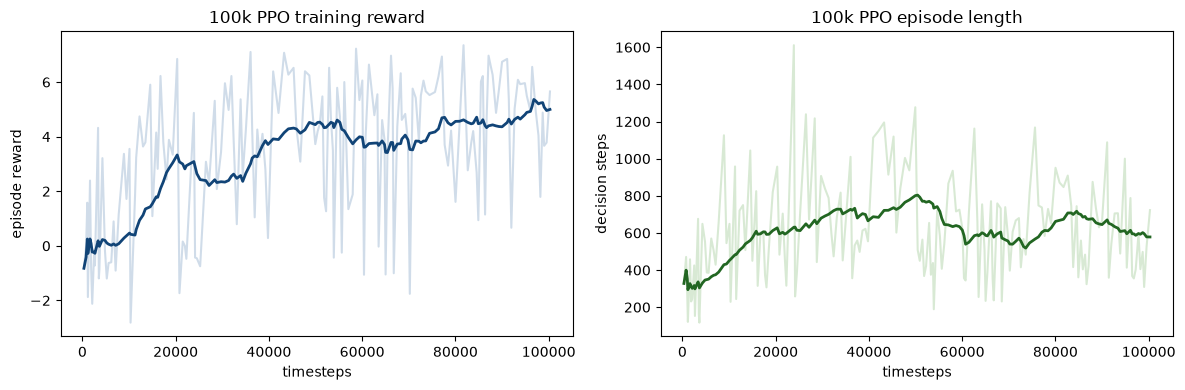

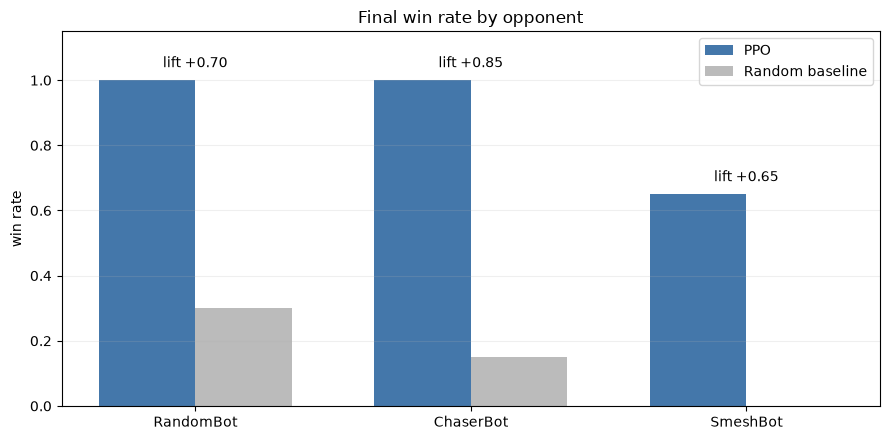

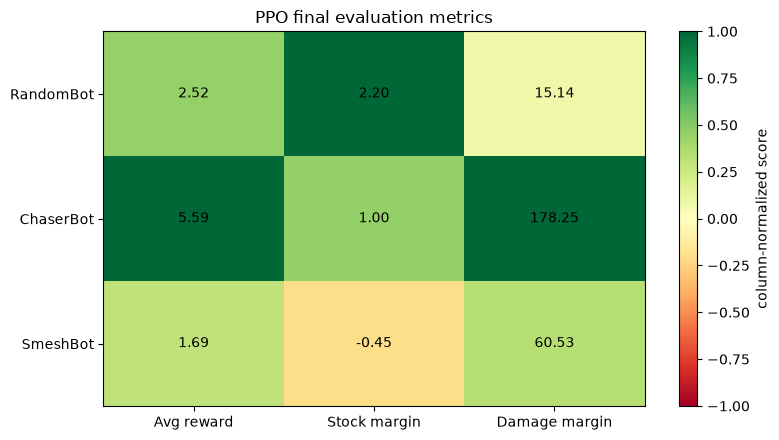

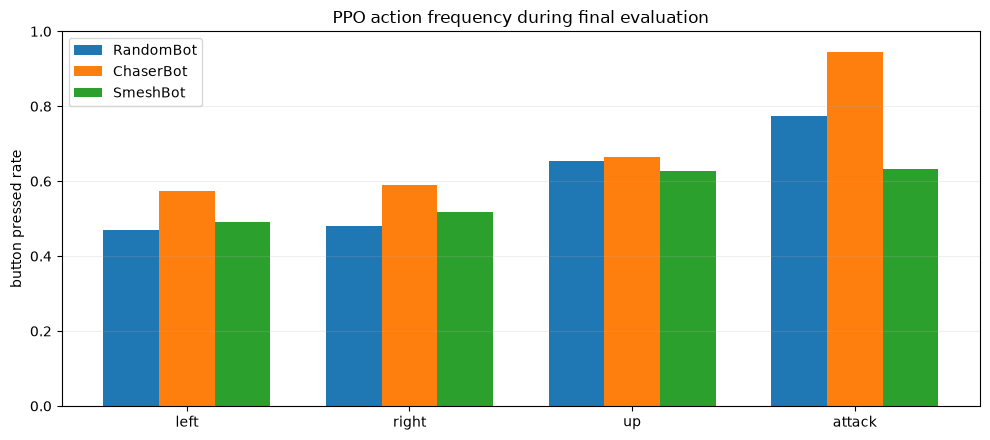

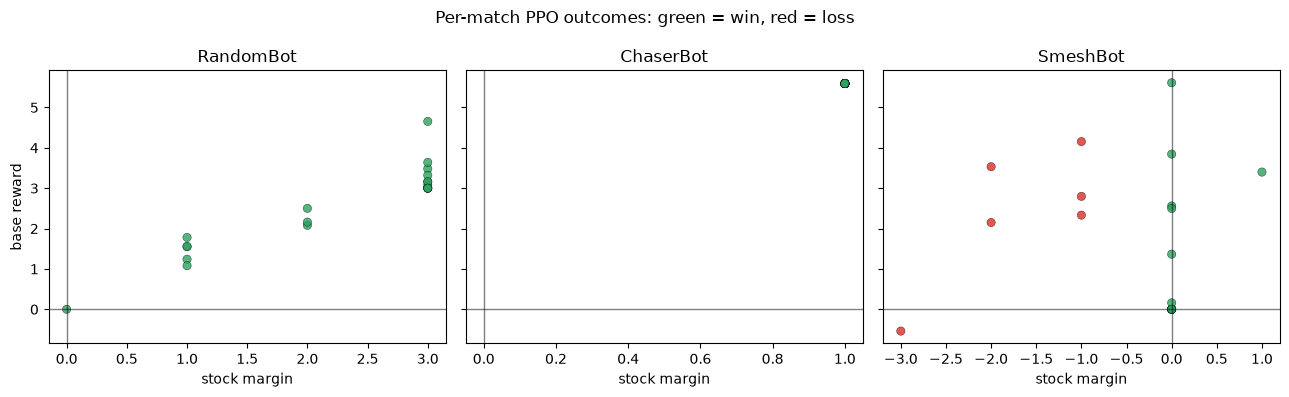

In [13]:
if final_results is not None:
    import matplotlib.pyplot as plt

    final_training = final_results["training_episodes"]
    final_ppo_rows = final_results["ppo_rows"]
    final_random_rows = final_results["random_rows"]
    final_action_summary = final_results["action_summary"]
    final_opponents = ["RandomBot", "ChaserBot", "SmeshBot"]

    def final_rows_for(rows, opponent):
        return [row for row in rows if row["opponent"] == opponent]

    def rolling_mean(values, window=20):
        return np.array([np.mean(values[max(0, i - window + 1) : i + 1]) for i in range(len(values))])

    # 1. Training curves.
    ts = np.array([row["timestep"] for row in final_training])
    rewards = np.array([row["reward"] for row in final_training])
    lengths = np.array([row["length"] for row in final_training])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(ts, rewards, alpha=0.25, color="#4477aa")
    axes[0].plot(ts, rolling_mean(rewards), color="#114477", lw=2)
    axes[0].set_title("100k PPO training reward")
    axes[0].set_xlabel("timesteps")
    axes[0].set_ylabel("episode reward")
    axes[1].plot(ts, lengths, alpha=0.25, color="#66aa55")
    axes[1].plot(ts, rolling_mean(lengths), color="#226622", lw=2)
    axes[1].set_title("100k PPO episode length")
    axes[1].set_xlabel("timesteps")
    axes[1].set_ylabel("decision steps")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "training_curves.png", dpi=180, bbox_inches="tight")

    # 2. Win-rate comparison.
    ppo_win_rates = [row["ppo_win_rate"] for row in final_result_table]
    random_win_rates = [row["random_win_rate"] for row in final_result_table]
    lifts = [row["baseline_lift"] for row in final_result_table]
    x = np.arange(len(final_opponents))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(x - width / 2, ppo_win_rates, width, label="PPO", color="#4477aa")
    ax.bar(x + width / 2, random_win_rates, width, label="Random baseline", color="#bbbbbb")
    for i, lift in enumerate(lifts):
        ax.text(i, max(ppo_win_rates[i], random_win_rates[i]) + 0.04, f"lift {lift:+.2f}", ha="center")
    ax.set_xticks(x, final_opponents)
    ax.set_ylim(0, 1.15)
    ax.set_title("Final win rate by opponent")
    ax.set_ylabel("win rate")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "win_rate_comparison.png", dpi=180, bbox_inches="tight")

    # 3. Metric heatmap.
    metrics = ["Avg reward", "Stock margin", "Damage margin"]
    values = np.array(
        [
            [row["ppo_avg_reward"], row["ppo_stock_margin"], row["ppo_damage_margin"]]
            for row in final_result_table
        ]
    )
    color_values = values.copy()
    for j in range(color_values.shape[1]):
        color_values[:, j] /= max(abs(color_values[:, j]).max(), 1e-9)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    im = ax.imshow(color_values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(len(metrics)), metrics)
    ax.set_yticks(np.arange(len(final_opponents)), final_opponents)
    ax.set_title("PPO final evaluation metrics")
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(j, i, f"{values[i, j]:.2f}", ha="center", va="center")
    fig.colorbar(im, ax=ax, label="column-normalized score")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "evaluation_metric_heatmap.png", dpi=180, bbox_inches="tight")

    # 4. Action frequencies.
    buttons = ["left", "right", "up", "attack"]
    x = np.arange(len(buttons))
    width = 0.25
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for idx, opponent in enumerate(final_opponents):
        rates = [final_action_summary[opponent][f"{button}_rate"] for button in buttons]
        ax.bar(x + (idx - 1) * width, rates, width, label=opponent)
    ax.set_xticks(x, buttons)
    ax.set_ylim(0, 1)
    ax.set_title("PPO action frequency during final evaluation")
    ax.set_ylabel("button pressed rate")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "action_frequency.png", dpi=180, bbox_inches="tight")

    # 5. Per-match outcomes.
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
    for ax, opponent in zip(axes, final_opponents):
        rows = final_rows_for(final_ppo_rows, opponent)
        rewards = [row["reward"] for row in rows]
        margins = [row["p0_stocks"] - row["p1_stocks"] for row in rows]
        colors = ["#2ca25f" if row["p0_win"] else "#de2d26" for row in rows]
        ax.scatter(margins, rewards, c=colors, alpha=0.8, edgecolor="black", linewidth=0.3)
        ax.axhline(0, color="black", lw=1, alpha=0.5)
        ax.axvline(0, color="black", lw=1, alpha=0.5)
        ax.set_title(opponent)
        ax.set_xlabel("stock margin")
    axes[0].set_ylabel("base reward")
    fig.suptitle("Per-match PPO outcomes: green = win, red = loss")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "per_match_outcomes.png", dpi=180, bbox_inches="tight")
else:
    print("Final dashboard skipped because no persisted final experiment was loaded.")


### Expanded 100-match evaluation

One limitation of the first evaluation was sample size: 20 matches per opponent is useful for iteration, but too small for a strong final claim. To address this, the final delivery includes a larger evaluation artifact with 100 PPO matches and 100 random-baseline matches per opponent. This gives narrower confidence intervals and a more defensible estimate of generalization to `SmeshBot`.


opponent   | eps | ppo_win |          95% CI | rnd_win |    lift |   reward |   stock |   damage
------------------------------------------------------------------------------------------------
RandomBot  | 100 |    0.98 |    [0.95, 1.00] |    0.25 |    0.73 |    2.480 |    2.20 |    10.68
ChaserBot  | 100 |    1.00 |    [1.00, 1.00] |    0.17 |    0.83 |    5.593 |    1.00 |   178.25
SmeshBot   | 100 |    0.67 |    [0.58, 0.76] |    0.00 |    0.67 |    1.539 |   -0.17 |    29.26


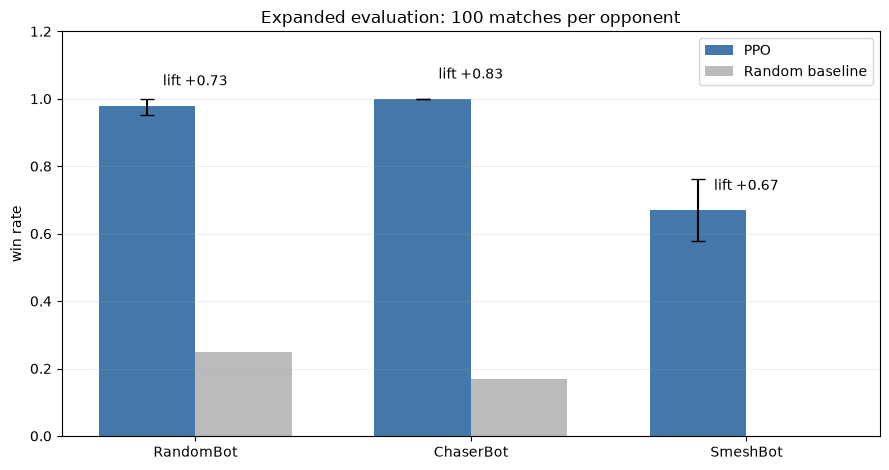

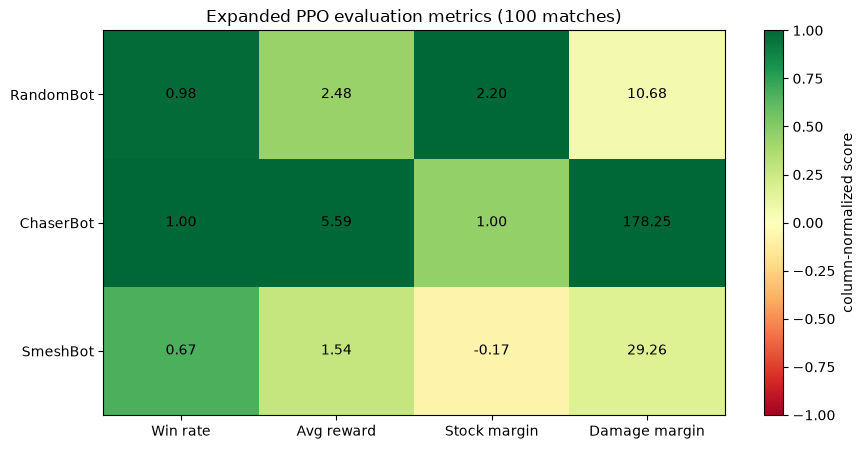

In [14]:
EVAL100_RESULTS_PATH = RESULTS_DIR / "ppo_final_chaser_100k_eval100_results.json"

if EVAL100_RESULTS_PATH.exists():
    eval100 = json.loads(EVAL100_RESULTS_PATH.read_text())

    def summarize_eval100(rows):
        wins = np.array([row["p0_win"] for row in rows], dtype=float)
        n = len(rows)
        p = float(np.mean(wins))
        half_width = 1.96 * np.sqrt(max(p * (1.0 - p), 0.0) / n)
        return {
            "episodes": n,
            "win_rate": p,
            "ci_low": max(0.0, p - half_width),
            "ci_high": min(1.0, p + half_width),
            "avg_reward": float(np.mean([row["reward"] for row in rows])),
            "avg_stock_margin": float(np.mean([row["p0_stocks"] - row["p1_stocks"] for row in rows])),
            "avg_damage_margin": float(np.mean([row["p1_damage"] - row["p0_damage"] for row in rows])),
        }

    eval100_table = []
    for opponent in ["RandomBot", "ChaserBot", "SmeshBot"]:
        ppo_subset = [row for row in eval100["ppo_rows"] if row["opponent"] == opponent]
        random_subset = [row for row in eval100["random_rows"] if row["opponent"] == opponent]
        ppo_summary = summarize_eval100(ppo_subset)
        random_summary = summarize_eval100(random_subset)
        eval100_table.append(
            {
                "opponent": opponent,
                "episodes": ppo_summary["episodes"],
                "ppo_win_rate": ppo_summary["win_rate"],
                "ci_low": ppo_summary["ci_low"],
                "ci_high": ppo_summary["ci_high"],
                "random_win_rate": random_summary["win_rate"],
                "lift": ppo_summary["win_rate"] - random_summary["win_rate"],
                "avg_reward": ppo_summary["avg_reward"],
                "stock_margin": ppo_summary["avg_stock_margin"],
                "damage_margin": ppo_summary["avg_damage_margin"],
            }
        )

    header = f"{'opponent':10s} | {'eps':>3s} | {'ppo_win':>7s} | {'95% CI':>15s} | {'rnd_win':>7s} | {'lift':>7s} | {'reward':>8s} | {'stock':>7s} | {'damage':>8s}"
    print(header)
    print("-" * len(header))
    for row in eval100_table:
        ci = f"[{row['ci_low']:.2f}, {row['ci_high']:.2f}]"
        print(
            f"{row['opponent']:10s} | {row['episodes']:3d} | {row['ppo_win_rate']:7.2f} | {ci:>15s} | "
            f"{row['random_win_rate']:7.2f} | {row['lift']:7.2f} | {row['avg_reward']:8.3f} | "
            f"{row['stock_margin']:7.2f} | {row['damage_margin']:8.2f}"
        )

    import matplotlib.pyplot as plt
    opponents = [row["opponent"] for row in eval100_table]
    x = np.arange(len(opponents))
    width = 0.35
    ppo_rates = [row["ppo_win_rate"] for row in eval100_table]
    random_rates = [row["random_win_rate"] for row in eval100_table]
    yerr = np.array(
        [
            [row["ppo_win_rate"] - row["ci_low"] for row in eval100_table],
            [row["ci_high"] - row["ppo_win_rate"] for row in eval100_table],
        ]
    )

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar(x - width / 2, ppo_rates, width, label="PPO", color="#4477aa", yerr=yerr, capsize=5)
    ax.bar(x + width / 2, random_rates, width, label="Random baseline", color="#bbbbbb")
    for i, row in enumerate(eval100_table):
        ax.text(i, max(ppo_rates[i], random_rates[i]) + 0.06, f"lift {row['lift']:+.2f}", ha="center")
    ax.set_xticks(x, opponents)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel("win rate")
    ax.set_title("Expanded evaluation: 100 matches per opponent")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "eval100_win_rate_ci.png", dpi=180, bbox_inches="tight")

    metrics = ["Win rate", "Avg reward", "Stock margin", "Damage margin"]
    values = np.array(
        [[row["ppo_win_rate"], row["avg_reward"], row["stock_margin"], row["damage_margin"]] for row in eval100_table],
        dtype=float,
    )
    color_values = values.copy()
    for j in range(color_values.shape[1]):
        color_values[:, j] /= max(abs(color_values[:, j]).max(), 1e-9)
    fig, ax = plt.subplots(figsize=(9, 4.6))
    im = ax.imshow(color_values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(len(metrics)), metrics)
    ax.set_yticks(np.arange(len(opponents)), opponents)
    ax.set_title("Expanded PPO evaluation metrics (100 matches)")
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(j, i, f"{values[i, j]:.2f}", ha="center", va="center")
    fig.colorbar(im, ax=ax, label="column-normalized score")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "eval100_metric_heatmap.png", dpi=180, bbox_inches="tight")
else:
    print("Expanded 100-match evaluation artifact not found.")


### Statistical significance tests

A strict data-science evaluation should test whether PPO's win-rate improvement over random actions is larger than expected by chance. For each opponent, I use a two-proportion z-test comparing PPO wins against random-baseline wins in the expanded 100-match evaluation.


In [15]:
STAT_TESTS_PATH = RESULTS_DIR / "statistical_tests_eval100.json"

if STAT_TESTS_PATH.exists():
    stat_tests = json.loads(STAT_TESTS_PATH.read_text())
else:
    from math import erf, sqrt

    def two_proportion_z_test(x1, n1, x2, n2):
        pooled = (x1 + x2) / (n1 + n2)
        se = np.sqrt(pooled * (1.0 - pooled) * (1.0 / n1 + 1.0 / n2))
        if se == 0:
            return float("inf"), 0.0
        z = (x1 / n1 - x2 / n2) / se
        p_value = 2.0 * (1.0 - 0.5 * (1.0 + erf(abs(z) / sqrt(2.0))))
        return float(z), float(p_value)

    stat_tests = []
    for opponent in ["RandomBot", "ChaserBot", "SmeshBot"]:
        ppo_subset = [row for row in eval100["ppo_rows"] if row["opponent"] == opponent]
        random_subset = [row for row in eval100["random_rows"] if row["opponent"] == opponent]
        x1 = sum(row["p0_win"] for row in ppo_subset)
        x2 = sum(row["p0_win"] for row in random_subset)
        z, p_value = two_proportion_z_test(x1, len(ppo_subset), x2, len(random_subset))
        stat_tests.append(
            {
                "opponent": opponent,
                "ppo_wins": int(x1),
                "ppo_n": len(ppo_subset),
                "random_wins": int(x2),
                "random_n": len(random_subset),
                "difference": x1 / len(ppo_subset) - x2 / len(random_subset),
                "z": z,
                "p_value": p_value,
            }
        )
    STAT_TESTS_PATH.write_text(json.dumps(stat_tests, indent=2))

header = f"{'opponent':10s} | {'PPO wins':>8s} | {'Random wins':>11s} | {'diff':>6s} | {'z':>6s} | {'p-value':>10s}"
print(header)
print("-" * len(header))
for row in stat_tests:
    p_text = "<1e-12" if row["p_value"] < 1e-12 else f"{row['p_value']:.2e}"
    print(
        f"{row['opponent']:10s} | {row['ppo_wins']:3d}/{row['ppo_n']:<3d} | "
        f"{row['random_wins']:3d}/{row['random_n']:<3d} | {row['difference']:6.2f} | "
        f"{row['z']:6.2f} | {p_text:>10s}"
    )


opponent   | PPO wins | Random wins |   diff |      z |    p-value
------------------------------------------------------------------
RandomBot  |  98/100 |  25/100 |   0.73 |  10.61 |     <1e-12
ChaserBot  | 100/100 |  17/100 |   0.83 |  11.91 |     <1e-12
SmeshBot   |  67/100 |   0/100 |   0.67 |  10.04 |     <1e-12


### Learned-agent benchmark

A stronger baseline suite compares PPO against the existing learned agents in the repository. The benchmark below uses the native `Match` loop with each candidate deployed as a `CharacterBrain`. This is a different protocol from the Gym wrapper evaluation, but it answers an important deployment question: how does PPO compare once all agents are plugged into the same game loop?


Learned-agent win rates, 50 matches per matchup
agent              |  Random |  Chaser |   Smesh |    mean
------------------------------------------------------------
PPO                |    1.00 |    1.00 |    1.00 |    1.00
QTable-Smesh       |    1.00 |    1.00 |    1.00 |    1.00
QTable-RoundRobin  |    1.00 |    1.00 |    1.00 |    1.00
DeepQ-Seq          |    0.26 |    1.00 |    0.14 |    0.47
DeepQ-All          |    0.68 |    1.00 |    0.28 |    0.65


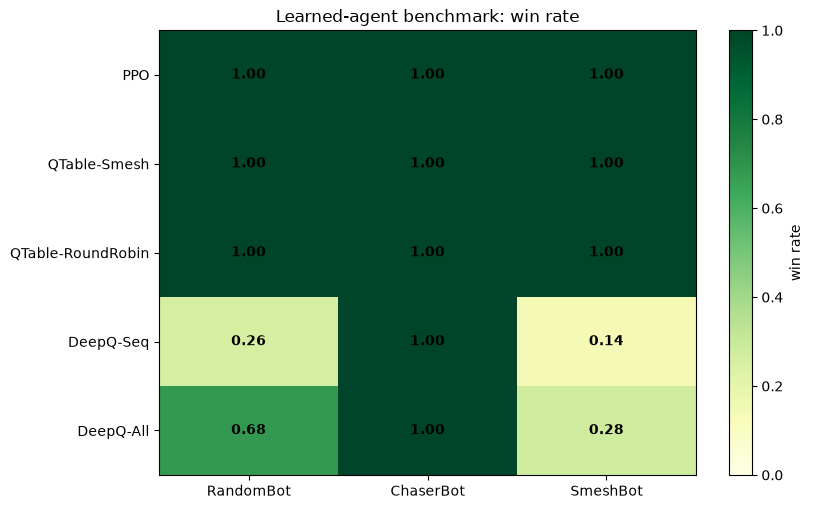

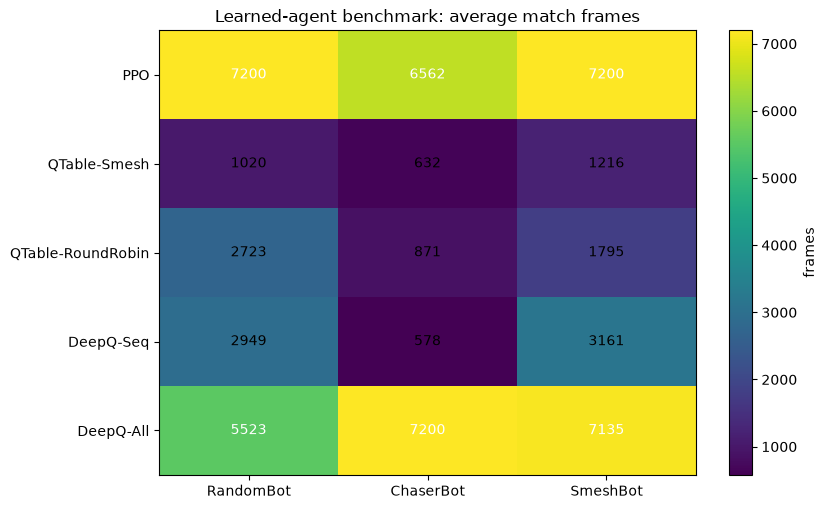

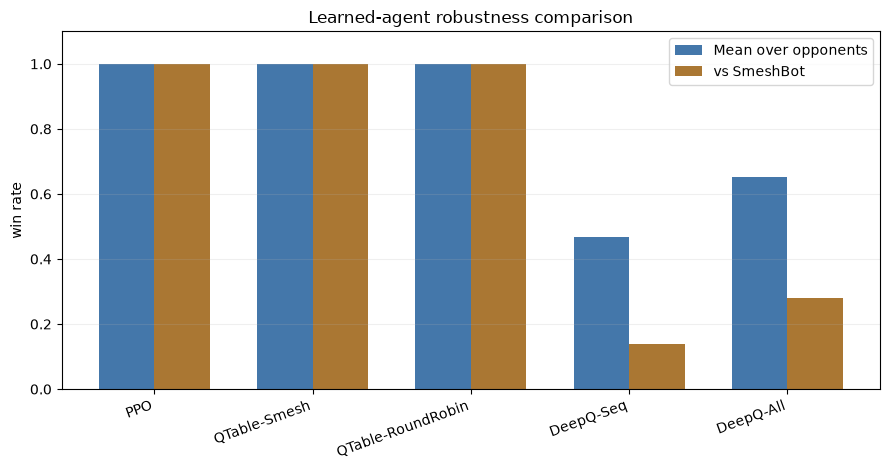

In [16]:
LEARNED_BENCHMARK_PATH = RESULTS_DIR / "learned_agent_benchmark_50x.json"

if LEARNED_BENCHMARK_PATH.exists():
    learned_benchmark = json.loads(LEARNED_BENCHMARK_PATH.read_text())
    benchmark_summary = learned_benchmark["summary"]
    benchmark_agents = ["PPO", "QTable-Smesh", "QTable-RoundRobin", "DeepQ-Seq", "DeepQ-All"]
    benchmark_opponents = ["RandomBot", "ChaserBot", "SmeshBot"]

    win_matrix = np.zeros((len(benchmark_agents), len(benchmark_opponents)))
    frame_matrix = np.zeros_like(win_matrix)
    for row in benchmark_summary:
        i = benchmark_agents.index(row["agent"])
        j = benchmark_opponents.index(row["opponent"])
        win_matrix[i, j] = row["win_rate"]
        frame_matrix[i, j] = row["avg_frames"]

    print("Learned-agent win rates, 50 matches per matchup")
    print(f"{'agent':18s} | {'Random':>7s} | {'Chaser':>7s} | {'Smesh':>7s} | {'mean':>7s}")
    print("-" * 60)
    for i, agent in enumerate(benchmark_agents):
        print(
            f"{agent:18s} | {win_matrix[i,0]:7.2f} | {win_matrix[i,1]:7.2f} | "
            f"{win_matrix[i,2]:7.2f} | {win_matrix[i].mean():7.2f}"
        )

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    im = ax.imshow(win_matrix, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(len(benchmark_opponents)), benchmark_opponents)
    ax.set_yticks(np.arange(len(benchmark_agents)), benchmark_agents)
    ax.set_title("Learned-agent benchmark: win rate")
    for i in range(win_matrix.shape[0]):
        for j in range(win_matrix.shape[1]):
            ax.text(j, i, f"{win_matrix[i, j]:.2f}", ha="center", va="center", fontweight="bold")
    fig.colorbar(im, ax=ax, label="win rate")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "learned_agent_winrate_heatmap.png", dpi=180, bbox_inches="tight")

    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    im = ax.imshow(frame_matrix, cmap="viridis", aspect="auto")
    ax.set_xticks(np.arange(len(benchmark_opponents)), benchmark_opponents)
    ax.set_yticks(np.arange(len(benchmark_agents)), benchmark_agents)
    ax.set_title("Learned-agent benchmark: average match frames")
    for i in range(frame_matrix.shape[0]):
        for j in range(frame_matrix.shape[1]):
            color = "white" if frame_matrix[i, j] > frame_matrix.max() / 2 else "black"
            ax.text(j, i, f"{frame_matrix[i, j]:.0f}", ha="center", va="center", color=color)
    fig.colorbar(im, ax=ax, label="frames")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "learned_agent_frames_heatmap.png", dpi=180, bbox_inches="tight")

    mean_win = win_matrix.mean(axis=1)
    smesh_win = win_matrix[:, 2]
    x = np.arange(len(benchmark_agents))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar(x - width / 2, mean_win, width, label="Mean over opponents", color="#4477aa")
    ax.bar(x + width / 2, smesh_win, width, label="vs SmeshBot", color="#aa7733")
    ax.set_xticks(x, benchmark_agents, rotation=20, ha="right")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("win rate")
    ax.set_title("Learned-agent robustness comparison")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "learned_agent_robustness_bar.png", dpi=180, bbox_inches="tight")
else:
    print("Learned-agent benchmark artifact not found.")


### Curriculum ablation

To address the single-opponent training limitation, I trained an additional PPO model for 100k timesteps using a naive round-robin curriculum over `RandomBot`, `ChaserBot`, and `SmeshBot`. The result is mixed and important: naive curriculum is not automatically better. It slightly improves SmeshBot win rate but catastrophically harms ChaserBot performance, so the Chaser-only PPO remains the final submitted policy.


opponent   | chaser-only | curriculum |   delta
--------------------------------------------------
RandomBot  |        0.98 |       1.00 |    0.02
ChaserBot  |        1.00 |       0.00 |   -1.00
SmeshBot   |        0.67 |       0.69 |    0.02


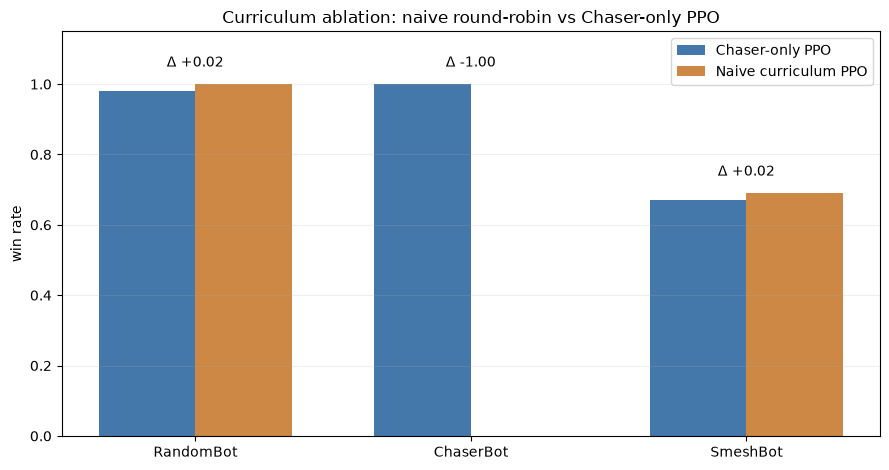

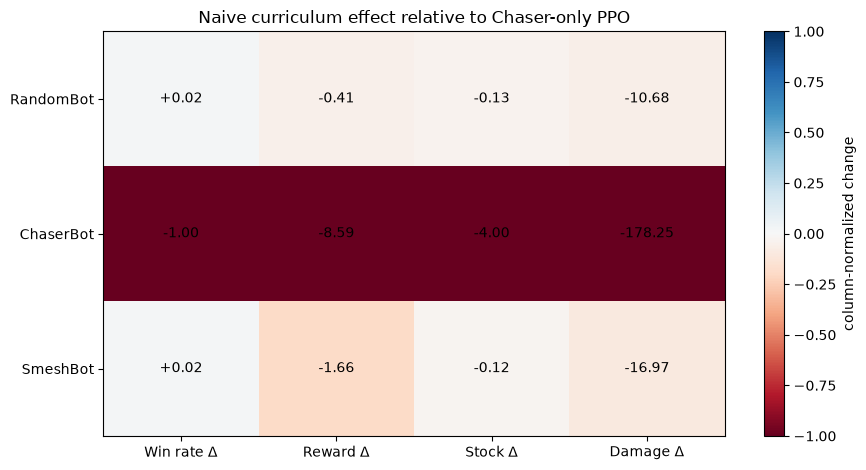

In [17]:
CURRICULUM_RESULTS_PATH = RESULTS_DIR / "ppo_curriculum_100k_eval100_results.json"
CURRICULUM_SUMMARY_PATH = RESULTS_DIR / "curriculum_ablation_summary.json"

if CURRICULUM_RESULTS_PATH.exists() and EVAL100_RESULTS_PATH.exists():
    curriculum_results = json.loads(CURRICULUM_RESULTS_PATH.read_text())
    chaser_only_results = json.loads(EVAL100_RESULTS_PATH.read_text())

    def summarize_policy_rows(rows):
        wins = np.array([row["p0_win"] for row in rows], dtype=float)
        return {
            "win_rate": float(np.mean(wins)),
            "avg_reward": float(np.mean([row["reward"] for row in rows])),
            "stock_margin": float(np.mean([row["p0_stocks"] - row["p1_stocks"] for row in rows])),
            "damage_margin": float(np.mean([row["p1_damage"] - row["p0_damage"] for row in rows])),
        }

    curriculum_table = []
    for opponent in ["RandomBot", "ChaserBot", "SmeshBot"]:
        base_rows = [row for row in chaser_only_results["ppo_rows"] if row["opponent"] == opponent]
        curr_rows = [row for row in curriculum_results["ppo_rows"] if row["opponent"] == opponent]
        base_summary = summarize_policy_rows(base_rows)
        curr_summary = summarize_policy_rows(curr_rows)
        curriculum_table.append(
            {
                "opponent": opponent,
                "chaser_only_win_rate": base_summary["win_rate"],
                "curriculum_win_rate": curr_summary["win_rate"],
                "win_delta": curr_summary["win_rate"] - base_summary["win_rate"],
                "reward_delta": curr_summary["avg_reward"] - base_summary["avg_reward"],
                "stock_delta": curr_summary["stock_margin"] - base_summary["stock_margin"],
                "damage_delta": curr_summary["damage_margin"] - base_summary["damage_margin"],
            }
        )

    print(f"{'opponent':10s} | {'chaser-only':>11s} | {'curriculum':>10s} | {'delta':>7s}")
    print("-" * 50)
    for row in curriculum_table:
        print(
            f"{row['opponent']:10s} | {row['chaser_only_win_rate']:11.2f} | "
            f"{row['curriculum_win_rate']:10.2f} | {row['win_delta']:7.2f}"
        )

    import matplotlib.pyplot as plt
    opponents = [row["opponent"] for row in curriculum_table]
    x = np.arange(len(opponents))
    width = 0.35
    base_rates = [row["chaser_only_win_rate"] for row in curriculum_table]
    curr_rates = [row["curriculum_win_rate"] for row in curriculum_table]

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar(x - width / 2, base_rates, width, label="Chaser-only PPO", color="#4477aa")
    ax.bar(x + width / 2, curr_rates, width, label="Naive curriculum PPO", color="#cc8844")
    for i, row in enumerate(curriculum_table):
        ax.text(i, max(base_rates[i], curr_rates[i]) + 0.05, f"Δ {row['win_delta']:+.2f}", ha="center")
    ax.set_xticks(x, opponents)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("win rate")
    ax.set_title("Curriculum ablation: naive round-robin vs Chaser-only PPO")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "curriculum_ablation_winrate.png", dpi=180, bbox_inches="tight")

    metrics = ["Win rate Δ", "Reward Δ", "Stock Δ", "Damage Δ"]
    values = np.array(
        [[row["win_delta"], row["reward_delta"], row["stock_delta"], row["damage_delta"]] for row in curriculum_table],
        dtype=float,
    )
    color_values = values.copy()
    for j in range(color_values.shape[1]):
        color_values[:, j] /= max(abs(color_values[:, j]).max(), 1e-9)
    fig, ax = plt.subplots(figsize=(9, 4.8))
    im = ax.imshow(color_values, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(len(metrics)), metrics)
    ax.set_yticks(np.arange(len(opponents)), opponents)
    ax.set_title("Naive curriculum effect relative to Chaser-only PPO")
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(j, i, f"{values[i, j]:+.2f}", ha="center", va="center")
    fig.colorbar(im, ax=ax, label="column-normalized change")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "curriculum_ablation_delta_heatmap.png", dpi=180, bbox_inches="tight")
else:
    print("Curriculum ablation artifacts not found.")


### Additional visual diagnostics

The plots below add distributional and behavioral context beyond the headline win rates. They help answer questions like: Are wins consistent or driven by outliers? Does PPO win by damage pressure or stock preservation? Did the policy collapse into a repetitive button pattern?


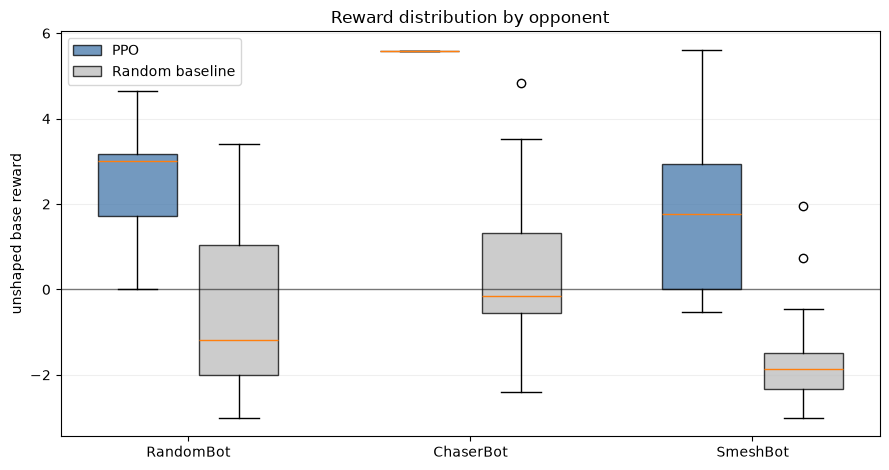

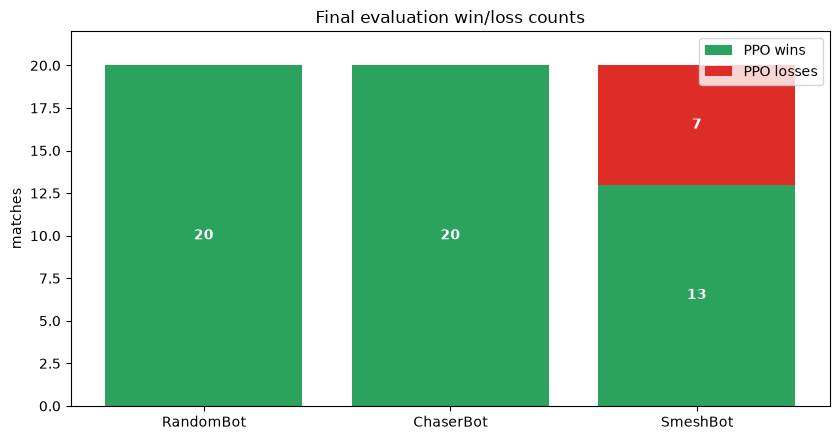

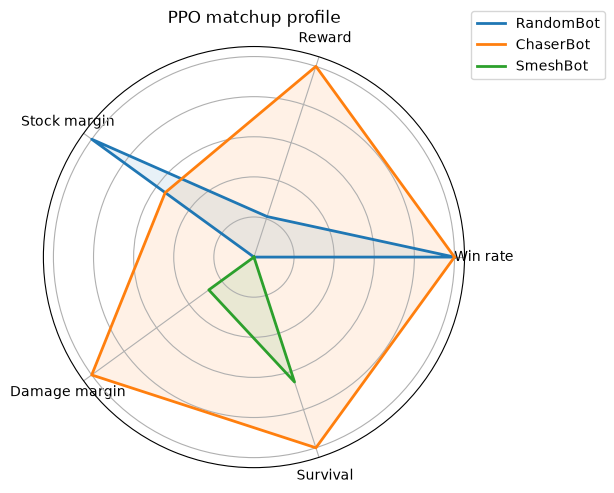

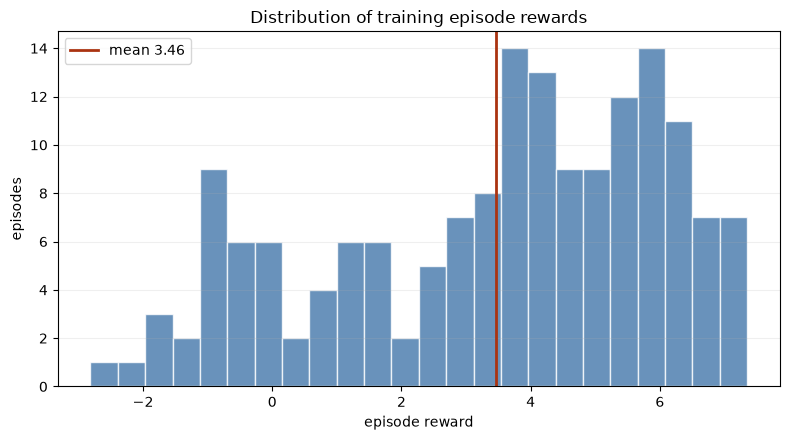

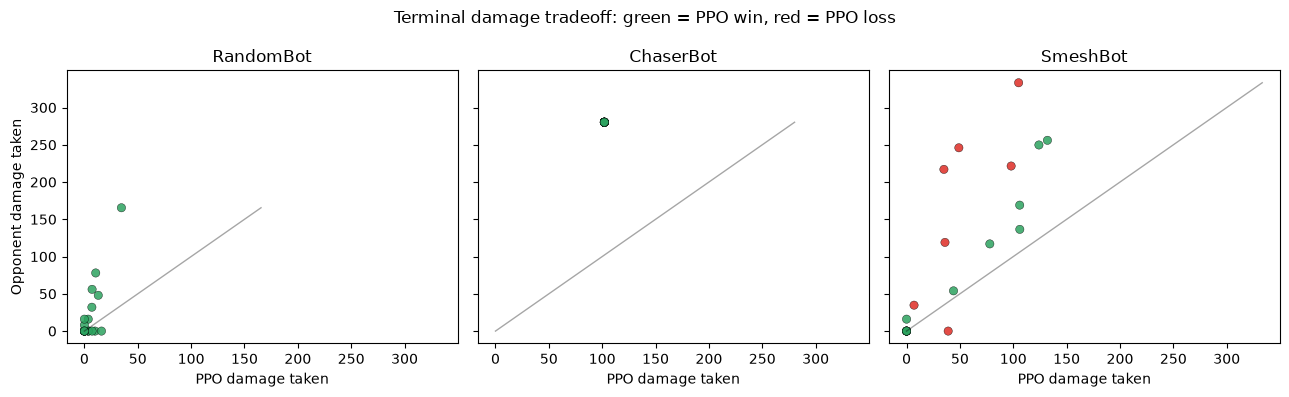

In [18]:
if final_results is not None:
    import matplotlib.pyplot as plt

    final_opponents = ["RandomBot", "ChaserBot", "SmeshBot"]
    final_ppo_rows = final_results["ppo_rows"]
    final_random_rows = final_results["random_rows"]
    final_training = final_results["training_episodes"]
    final_action_summary = final_results["action_summary"]

    def rows_for_plot(rows, opponent):
        return [row for row in rows if row["opponent"] == opponent]

    # Reward distribution by opponent.
    positions = np.arange(len(final_opponents))
    ppo_rewards = [[row["reward"] for row in rows_for_plot(final_ppo_rows, opp)] for opp in final_opponents]
    random_rewards = [[row["reward"] for row in rows_for_plot(final_random_rows, opp)] for opp in final_opponents]
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ppo_box = ax.boxplot(ppo_rewards, positions=positions - 0.18, widths=0.28, patch_artist=True, manage_ticks=False)
    random_box = ax.boxplot(random_rewards, positions=positions + 0.18, widths=0.28, patch_artist=True, manage_ticks=False)
    for patch in ppo_box["boxes"]:
        patch.set_facecolor("#4477aa")
        patch.set_alpha(0.75)
    for patch in random_box["boxes"]:
        patch.set_facecolor("#bbbbbb")
        patch.set_alpha(0.75)
    ax.set_xticks(positions, final_opponents)
    ax.axhline(0, color="black", lw=1, alpha=0.5)
    ax.set_ylabel("unshaped base reward")
    ax.set_title("Reward distribution by opponent")
    ax.legend([ppo_box["boxes"][0], random_box["boxes"][0]], ["PPO", "Random baseline"])
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "reward_distribution_boxplot.png", dpi=180, bbox_inches="tight")

    # Win/loss counts.
    wins = np.array([sum(row["p0_win"] for row in rows_for_plot(final_ppo_rows, opp)) for opp in final_opponents])
    losses = np.array([20 - win for win in wins])
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.bar(final_opponents, wins, label="PPO wins", color="#2ca25f")
    ax.bar(final_opponents, losses, bottom=wins, label="PPO losses", color="#de2d26")
    for i, (win_count, loss_count) in enumerate(zip(wins, losses)):
        if win_count:
            ax.text(i, win_count / 2, str(int(win_count)), ha="center", va="center", color="white", fontweight="bold")
        if loss_count:
            ax.text(i, win_count + loss_count / 2, str(int(loss_count)), ha="center", va="center", color="white", fontweight="bold")
    ax.set_ylim(0, 22)
    ax.set_title("Final evaluation win/loss counts")
    ax.set_ylabel("matches")
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "win_loss_counts.png", dpi=180, bbox_inches="tight")

    # Radar profile with normalized metrics.
    radar_labels = ["Win rate", "Reward", "Stock margin", "Damage margin", "Survival"]
    angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
    angles += angles[:1]
    raw_profile = np.array(
        [
            [row["ppo_win_rate"], row["ppo_avg_reward"], row["ppo_stock_margin"], row["ppo_damage_margin"], row["ppo_avg_frames"]]
            for row in final_result_table
        ],
        dtype=float,
    )
    normalized_profile = raw_profile.copy()
    for j in range(normalized_profile.shape[1]):
        col = normalized_profile[:, j]
        normalized_profile[:, j] = (col - col.min()) / (col.max() - col.min() if col.max() > col.min() else 1.0)
    fig, ax = plt.subplots(figsize=(6.4, 6.4), subplot_kw=dict(polar=True))
    for values, opponent in zip(normalized_profile, final_opponents):
        closed = values.tolist() + values[:1].tolist()
        ax.plot(angles, closed, lw=2, label=opponent)
        ax.fill(angles, closed, alpha=0.10)
    ax.set_xticks(angles[:-1], radar_labels)
    ax.set_yticklabels([])
    ax.set_title("PPO matchup profile")
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "matchup_radar_profile.png", dpi=180, bbox_inches="tight")

    # Training reward histogram.
    rewards = np.array([row["reward"] for row in final_training])
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(rewards, bins=24, color="#4477aa", alpha=0.8, edgecolor="white")
    ax.axvline(rewards.mean(), color="#aa3311", lw=2, label=f"mean {rewards.mean():.2f}")
    ax.set_title("Distribution of training episode rewards")
    ax.set_xlabel("episode reward")
    ax.set_ylabel("episodes")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "training_reward_histogram.png", dpi=180, bbox_inches="tight")

    # Terminal damage tradeoff.
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
    for ax, opponent in zip(axes, final_opponents):
        rows = rows_for_plot(final_ppo_rows, opponent)
        x_damage = [row["p0_damage"] for row in rows]
        y_damage = [row["p1_damage"] for row in rows]
        colors = ["#2ca25f" if row["p0_win"] else "#de2d26" for row in rows]
        ax.scatter(x_damage, y_damage, c=colors, alpha=0.85, edgecolor="black", linewidth=0.3)
        max_value = max(max(x_damage or [0]), max(y_damage or [0]), 1)
        ax.plot([0, max_value], [0, max_value], color="black", lw=1, alpha=0.35)
        ax.set_title(opponent)
        ax.set_xlabel("PPO damage taken")
    axes[0].set_ylabel("Opponent damage taken")
    fig.suptitle("Terminal damage tradeoff: green = PPO win, red = PPO loss")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "terminal_damage_tradeoff.png", dpi=180, bbox_inches="tight")
else:
    print("Additional visual diagnostics skipped because no persisted final experiment was loaded.")


### Behavioral diagnostics

A policy can have a decent score for the wrong reason, so the final experiment also records action frequencies. This is a coarse behavioral check: a collapsed policy that never attacks, never moves, or only jumps would be easy to spot here.


In [19]:
if final_results is not None and final_results.get("action_summary"):
    for opponent, rates in final_results["action_summary"].items():
        print(
            f"{opponent:10s} | decisions={rates['n_decisions']:5d} "
            f"left={rates['left_rate']:.2f} right={rates['right_rate']:.2f} "
            f"up={rates['up_rate']:.2f} attack={rates['attack_rate']:.2f}"
        )
else:
    print("No action-frequency diagnostics are available.")


RandomBot  | decisions=27617 left=0.47 right=0.48 up=0.66 attack=0.77
ChaserBot  | decisions=36000 left=0.57 right=0.59 up=0.66 attack=0.94
SmeshBot   | decisions=33108 left=0.49 right=0.52 up=0.63 attack=0.63


### MLflow experiment tracking

The final PPO experiment is logged to a local MLflow SQLite backend. This records hyperparameters, metrics, figures, the checkpoint, the notebook, and the final report. To inspect it interactively from the repository root, run:

```bash
.venv311/bin/mlflow ui --backend-store-uri sqlite:///results/mlflow_tracking.db
```

Then open the local MLflow UI URL shown in the terminal.


In [20]:
if final_results is not None:
    try:
        import mlflow
        from mlflow.tracking import MlflowClient

        tracking_db = RESULTS_DIR / "mlflow_tracking.db"
        artifact_root = RESULTS_DIR / "mlflow_artifacts"
        artifact_root.mkdir(exist_ok=True)
        tracking_uri = f"sqlite:///{tracking_db}"
        experiment_name = "ppo_smeshlite_final"
        mlflow.set_tracking_uri(tracking_uri)
        client = MlflowClient(tracking_uri=tracking_uri)
        experiment = client.get_experiment_by_name(experiment_name)
        if experiment is None:
            experiment_id = client.create_experiment(experiment_name, artifact_location=artifact_root.as_uri())
        else:
            experiment_id = experiment.experiment_id

        with mlflow.start_run(experiment_id=experiment_id, run_name="ppo_chaser_100k_final") as run:
            run_id = run.info.run_id
            mlflow.set_tags(
                {
                    "algorithm": "PPO",
                    "environment": "SmeshLite",
                    "training_opponent": "ChaserBot",
                    "evaluation_opponents": "RandomBot,ChaserBot,SmeshBot",
                    "delivery": "final_assignment",
                }
            )
            mlflow.log_params(
                {
                    "seed": final_results["seed"],
                    "timesteps": final_results["timesteps"],
                    "policy": "MlpPolicy",
                    "learning_rate": 3e-4,
                    "n_steps": 1024,
                    "batch_size": 256,
                    "n_epochs": 8,
                    "gamma": 0.995,
                    "gae_lambda": 0.95,
                    "clip_range": 0.2,
                    "ent_coef": 0.01,
                    "vf_coef": 0.5,
                    "frame_skip": 4,
                    "eval_episodes_per_opponent": 20,
                }
            )
            mlflow.log_metric("training_seconds", final_results["training_seconds"])
            mlflow.log_metric("training_episodes", len(final_results["training_episodes"]))
            for row in final_result_table:
                prefix = row["opponent"].lower()
                mlflow.log_metric(f"{prefix}_ppo_win_rate", row["ppo_win_rate"])
                mlflow.log_metric(f"{prefix}_random_win_rate", row["random_win_rate"])
                mlflow.log_metric(f"{prefix}_baseline_lift", row["baseline_lift"])
                mlflow.log_metric(f"{prefix}_ppo_avg_reward", row["ppo_avg_reward"])
                mlflow.log_metric(f"{prefix}_ppo_stock_margin", row["ppo_stock_margin"])
                mlflow.log_metric(f"{prefix}_ppo_damage_margin", row["ppo_damage_margin"])
            mlflow.log_metric("mean_ppo_win_rate", float(np.mean([row["ppo_win_rate"] for row in final_result_table])))
            mlflow.log_metric("mean_baseline_lift", float(np.mean([row["baseline_lift"] for row in final_result_table])))
            if "eval100_table" in globals():
                mlflow.log_param("expanded_eval_episodes_per_opponent", 100)
                for row in eval100_table:
                    prefix = row["opponent"].lower()
                    mlflow.log_metric(f"{prefix}_eval100_ppo_win_rate", row["ppo_win_rate"])
                    mlflow.log_metric(f"{prefix}_eval100_random_win_rate", row["random_win_rate"])
                    mlflow.log_metric(f"{prefix}_eval100_baseline_lift", row["lift"])
                    mlflow.log_metric(f"{prefix}_eval100_ppo_avg_reward", row["avg_reward"])
                    mlflow.log_metric(f"{prefix}_eval100_ppo_stock_margin", row["stock_margin"])
                    mlflow.log_metric(f"{prefix}_eval100_ppo_damage_margin", row["damage_margin"])
                mlflow.log_metric("eval100_mean_ppo_win_rate", float(np.mean([row["ppo_win_rate"] for row in eval100_table])))
                mlflow.log_metric("eval100_mean_baseline_lift", float(np.mean([row["lift"] for row in eval100_table])))

            mlflow.log_artifact(str(FINAL_RESULTS_PATH), artifact_path="results")
            if EVAL100_RESULTS_PATH.exists():
                mlflow.log_artifact(str(EVAL100_RESULTS_PATH), artifact_path="results")
            if "STAT_TESTS_PATH" in globals() and STAT_TESTS_PATH.exists():
                mlflow.log_artifact(str(STAT_TESTS_PATH), artifact_path="results")
                for row in stat_tests:
                    prefix = row["opponent"].lower()
                    mlflow.log_metric(f"{prefix}_ppo_vs_random_win_diff", row["difference"])
                    mlflow.log_metric(f"{prefix}_ppo_vs_random_p_value", row["p_value"])
            if "LEARNED_BENCHMARK_PATH" in globals() and LEARNED_BENCHMARK_PATH.exists():
                mlflow.log_artifact(str(LEARNED_BENCHMARK_PATH), artifact_path="results")
                for row in benchmark_summary:
                    prefix = f"benchmark_{row['agent'].lower().replace('-', '_')}_vs_{row['opponent'].lower()}"
                    mlflow.log_metric(f"{prefix}_win_rate", row["win_rate"])
                    mlflow.log_metric(f"{prefix}_avg_frames", row["avg_frames"])
            if "CURRICULUM_RESULTS_PATH" in globals() and CURRICULUM_RESULTS_PATH.exists():
                mlflow.log_artifact(str(CURRICULUM_RESULTS_PATH), artifact_path="results")
                if CURRICULUM_SUMMARY_PATH.exists():
                    mlflow.log_artifact(str(CURRICULUM_SUMMARY_PATH), artifact_path="results")
                for row in curriculum_table:
                    prefix = row["opponent"].lower()
                    mlflow.log_metric(f"curriculum_{prefix}_win_rate", row["curriculum_win_rate"])
                    mlflow.log_metric(f"curriculum_{prefix}_win_delta_vs_chaser_only", row["win_delta"])
            for figure_path in sorted(FIGURE_DIR.glob("*.png")):
                mlflow.log_artifact(str(figure_path), artifact_path="figures")
            for artifact_path in [PROJECT_ROOT / "ppo_smeshlite_training.ipynb", PROJECT_ROOT / "PPO_SmeshLite_Final_Report.md"]:
                if artifact_path.exists():
                    mlflow.log_artifact(str(artifact_path), artifact_path="delivery")
            final_checkpoint = CHECKPOINT_DIR / "ppo_smeshlite_final_chaser_100k.zip"
            if final_checkpoint.exists():
                mlflow.log_artifact(str(final_checkpoint), artifact_path="checkpoints")

        mlflow_summary = {
            "experiment": experiment_name,
            "run_name": "ppo_chaser_100k_final",
            "run_id": run_id,
            "tracking_uri": tracking_uri,
            "artifact_root": artifact_root.as_uri(),
        }
        (RESULTS_DIR / "mlflow_ppo_final_run.json").write_text(json.dumps(mlflow_summary, indent=2))
        print("Logged MLflow run:", run_id)
        print("Tracking URI:", tracking_uri)
    except ImportError:
        print("MLflow is not installed. Install it with: pip install -e '.[tracking]'")
else:
    print("MLflow logging skipped because no persisted final experiment was loaded.")


Logged MLflow run: 44125876a4cf4469bc08ef15c9490afc
Tracking URI: sqlite:////Users/jyaruhernandez/Documents/proyecto_final_ml_II/SmeshLite/results/mlflow_tracking.db


## 8. Save checkpoint and use it as a game brain

Analysis:

The existing `agents/sb3_template.py` loads a PPO checkpoint and feeds it the raw 22-float observation. This notebook trains on normalized observations, so inference needs to apply the same `normalize_smeshlite_obs()` function before calling `model.predict()`.

The `PPOBrain` adapter below shows exactly how to deploy the notebook-trained checkpoint back into a normal `Match` without modifying project code.

In [21]:
checkpoint_path = CHECKPOINT_DIR / "ppo_smeshlite_chaser.zip"
model.save(checkpoint_path)
print("Saved PPO checkpoint:", checkpoint_path)


class PPOBrain(CharacterBrain):
    """CharacterBrain adapter for a PPO model trained in this notebook."""

    BRAIN_NAME = "PPO Bot (notebook)"

    def __init__(self, checkpoint: str | os.PathLike = checkpoint_path, deterministic: bool = True) -> None:
        self.model = PPO.load(str(checkpoint))
        self.deterministic = deterministic

    def think(self, context: BrainContext, out: InputState) -> None:
        raw_obs = np.array(brain_context_to_obs(context), dtype=np.float32)
        obs = normalize_smeshlite_obs(raw_obs)
        action, _ = self.model.predict(obs, deterministic=self.deterministic)
        out.left = bool(action[0])
        out.right = bool(action[1])
        out.up = bool(action[2])
        out.attack = bool(action[3])


print("PPOBrain is ready for Match.set_player_brain(...).")

Saved PPO checkpoint: /Users/jyaruhernandez/Documents/proyecto_final_ml_II/SmeshLite/agents/checkpoints/ppo_smeshlite_chaser.zip
PPOBrain is ready for Match.set_player_brain(...).


In [22]:
# One short headless match smoke test using the saved checkpoint through the CharacterBrain API.
from smeshlite.core.match import Match, MatchConfig

match = Match(MatchConfig(time_limit=1200))
match.reset(n_players=2)
match.set_player_brain(0, PPOBrain(str(checkpoint_path)))
match.set_player_brain(1, ChaserBot())

while not match.done:
    match.tick()

print(
    "winner:", match.winner,
    "frames:", match.frame,
    "p0 damage/stocks:", match.characters[0].damage_pct, match.characters[0].stocks,
    "p1 damage/stocks:", match.characters[1].damage_pct, match.characters[1].stocks,
)

winner: 1 frames: 1200 p0 damage/stocks: 0.0 2 p1 damage/stocks: 0.0 3


## 9. Final interpretation and conclusions

This notebook implements PPO as a clean neural-policy baseline for SmeshLite and evaluates it with fight-level metrics rather than relying only on training reward.

Expected interpretation pattern:

- If PPO beats random actions against `RandomBot` and `ChaserBot`, the policy learned more than noise and can exploit simple opponents.
- If PPO performs poorly against `SmeshBot`, that is not a failure of the pipeline; it shows limited transfer from a simple training opponent to a more strategic opponent with recovery and charging logic.
- If stock margin is negative while damage margin is positive, the policy can deal damage but still loses stocks through positioning or recovery errors.
- If both stock and damage margins are negative, the next research step should prioritize curriculum training and stronger recovery shaping.

Limitations:

- PPO was trained from compact state features, not pixels; the policy learns from engineered observations.
- A single-opponent training distribution can overfit.
- The random baseline is necessary but not sufficient; future work should compare against the existing Q-table and DQN checkpoints using identical evaluation seeds.
- The 95% confidence intervals are approximate and become meaningful only with enough evaluation episodes.

Final conclusion:

PPO is technically compatible with SmeshLite and can be deployed as a standard `CharacterBrain`. The most important research result is the experimental framework: normalized Gym wrapper, reproducible PPO training, explicit baseline comparison, behavioral diagnostics, and transferable checkpoint adapter. For stronger gameplay performance, the next best experiment is curriculum PPO trained sequentially against `RandomBot`, `ChaserBot`, `SmeshBot`, and older PPO snapshots.
